#  🍄 SUSTAIN 🍄
### A Practical Example
Inspired by the famous edible-mushroom problem, we aim to solve it using technology from the 80s! I this notebook
we are trying to classify the mushrooms based on their features.

Big shootout for the creators of the dataset: https://archive.ics.uci.edu/dataset/73/mushroom !

### (1) Preprocessing
We will load the dataset and then encode a few chosen features of mushrooms as vectors.


In [91]:
import numpy as np
import pandas as pd
import os

In [92]:
print(f"working dir: {os.getcwd()}")

working dir: C:\Users\kalus\PycharmProjects\SUSTAIN-replication


In [93]:
df = pd.read_csv("notebooks/datasets/mushrooms.csv", sep=",", encoding="utf-8")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [94]:
# the most important variables are class
df.sample(4)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
3568,e,f,y,e,t,n,f,c,b,u,...,s,g,w,p,w,o,p,n,v,d
7632,e,x,s,w,f,n,f,w,b,w,...,k,w,w,p,w,t,p,w,n,g
2924,e,x,y,g,t,n,f,c,b,n,...,s,p,w,p,w,o,p,k,y,d
5227,p,x,y,n,f,f,f,c,n,b,...,k,w,w,p,w,o,e,w,v,d


What we have to do now is to transform the output into the list readable for SUSTAIN.

### (2) Encoding
Now, we need to encode the stimuli as vectors suitable for SUSTAIN.

In [95]:
from importlib import reload
from src.expretimetnal_tools import encode_stimuli
reload(src.expretimetnal_tools)

# 70/30 split
split_index = int(len(df) * 0.70)
data_train = df.iloc[:split_index]
data_test = df.iloc[split_index:]

train_encoded_stimuli, dim_sizes_train = encode_stimuli(data_train)
test_encoded_stimuli, dim_sizes_test = encode_stimuli(data_test)

# queried dim: 0 =

We must combine the dim_sizes. Why? SUSTAIN internal weights are built expecting up to n values. Thus, different dimensions are not a problem when working with lower dimensions than expected. However, they are a huge problem when working with higher dimensions than expected (e.g. when the train set has fewer dimensions than the test set).

In [96]:
dim_sizes_combined = [max(a, b) for a, b in zip(dim_sizes_train, dim_sizes_test)]
print(len(test_encoded_stimuli))
print(f"dim_sizes_combined: {dim_sizes_combined}")

2438
dim_sizes_combined: [2, 6, 4, 10, 2, 8, 2, 2, 2, 11, 2, 5, 4, 4, 8, 8, 1, 4, 3, 5, 7, 6, 7]


### (3) Test run
Let's see how SUSTAIN actually performs. We are going to run it in the following fashion: first let's SUSTAIN in supervised mode first in order to train its prediction of a given class: poisonous/nonpoinsoneuss.

In [110]:
from importlib import reload
import src.expretimetnal_tools
reload(src.expretimetnal_tools)
from src.expretimetnal_tools import run_sustain_on_data
from src.sustain import SUSTAIN

model = SUSTAIN(r=2.844642,
                beta=2.386305,
                d=12.0,
                eta=0.09361126,
                supervised=True,
                queried_dim=0)

model.reset(dim_sizes=dim_sizes_combined)

# just for training
_, trained_model = run_sustain_on_data(model=model, data=train_encoded_stimuli, queried_dim=0)

# real test
results, _ = run_sustain_on_data(model=trained_model, data=test_encoded_stimuli, queried_dim=0)

In [111]:
results.head(5)

,response,probability,correct,n_clusters,winner,recruited
index,,,,,,
0,1,"[0.4618684483882979, 0.5381315516117021]",True,7,2,False
1,0,"[0.5712751435934278, 0.42872485640657215]",True,7,0,False
2,1,"[0.4699064716392441, 0.5300935283607559]",True,7,1,False
3,1,"[0.49739977461528895, 0.502600225384711]",True,7,4,False
4,0,"[0.5, 0.5]",False,8,7,True


It's a good time to visuzalize the results.

In [114]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

count_true  = (results["correct"] == True).sum()
count_false = (results["correct"] == False).sum()

# edible = negative = 0
# poisonous = positive = 1

true_positive = ((results["correct"] == True) & (results["response"] == 1)).sum()
true_negative = ((results["correct"] == True) & (results["response"] == 0)).sum()
false_positive = ((results["correct"] == False) & (results["response"] == 1)).sum()
false_negative = ((results["correct"] == False) & (results["response"] == 0)).sum()

accuracy  = round(count_true / (count_false + count_true), 3)
precision = round(true_positive / (true_positive + false_positive), 3) if (true_positive + false_positive) > 0 else 0.0
recall = round(true_positive / (true_positive + false_negative), 3) if (true_positive + false_negative) > 0 else 0.0
f1 = round(2 * (precision * recall) / (precision + recall), 3)  if (precision + recall) > 0 else 0.0

print(f"ACC: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

ACC: 0.9
Precision: 1.0
Recall: 0.812
F1: 0.896


### (4) Repeated testing
Now we will repeat the procedure a houndres times to make our results more stable.



In [129]:
from sklearn.model_selection import train_test_split
import src.expretimetnal_tools
reload(src.expretimetnal_tools)

accuracy_collection = []
precision_collection = []
recall_collection = []
f1_collection = []

# take a random subset of the dataset
df = pd.read_csv("notebooks/datasets/mushrooms.csv", sep=",", encoding="utf-8")
df = df.sample(1000)
trails = [i for i in range(100)]
for i in trails:

    # randomly split the data
    data_train, data_test = train_test_split(df, test_size=0.30, random_state=i)

    train_encoded_stimuli, dim_sizes_train = encode_stimuli(data_train)
    test_encoded_stimuli, dim_sizes_test = encode_stimuli(data_test)
    dim_sizes_combined = [max(a, b) for a, b in zip(dim_sizes_train, dim_sizes_test)]

    model = SUSTAIN(r=2.844642,
                    beta=2.386305,
                    d=12.0,
                    eta=0.09361126,
                    supervised=True,
                    queried_dim=0)

    model.reset(dim_sizes=dim_sizes_combined)

    # just for training
    _, trained_model = run_sustain_on_data(model=model, data=train_encoded_stimuli, queried_dim=0)

    # real test
    results, _ = run_sustain_on_data(model=trained_model, data=test_encoded_stimuli, queried_dim=0)

    # compute stats (as above)
    count_true  = (results["correct"] == True).sum()
    count_false = (results["correct"] == False).sum()

    true_positive = ((results["correct"] == True) & (results["response"] == 1)).sum()
    true_negative = ((results["correct"] == True) & (results["response"] == 0)).sum()
    false_positive = ((results["correct"] == False) & (results["response"] == 1)).sum()
    false_negative = ((results["correct"] == False) & (results["response"] == 0)).sum()

    accuracy  = round(count_true / (count_false + count_true), 3)
    precision = round(true_positive / (true_positive + false_positive), 3) if (true_positive + false_positive) > 0 else 0.0
    recall = round(true_positive / (true_positive + false_negative), 3) if (true_positive + false_negative) > 0 else 0.0
    f1 = round(2 * (precision * recall) / (precision + recall), 3)  if (precision + recall) > 0 else 0.0

    # append the results
    accuracy_collection.append(accuracy)
    precision_collection.append(precision)
    recall_collection.append(recall)
    f1_collection.append(f1)

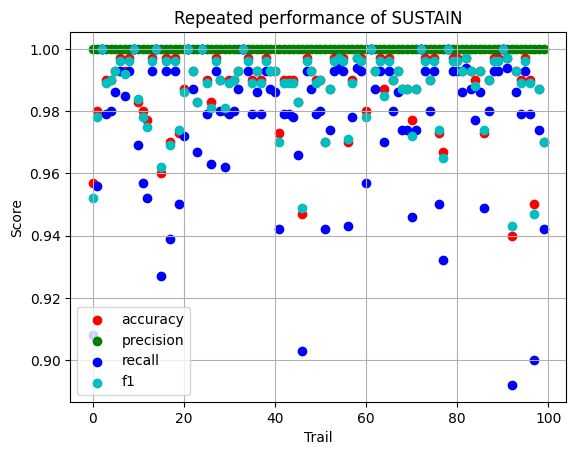

In [130]:
plt.scatter(trails, accuracy_collection, color='r', label='accuracy')
plt.scatter(trails, precision_collection, color='g', label='precision')
plt.scatter(trails, recall_collection, color='b', label='recall')
plt.scatter(trails, f1_collection, color='c', label='f1')

plt.xlabel("Trail")
plt.ylabel("Score")
plt.title("Repeated performance of SUSTAIN")
plt.grid(True)
plt.legend()
plt.show()

In [136]:
import numpy as np
print(f"Mean Accuracy: {round(np.mean(accuracy_collection), 2)}")
print(f"Accuracy SD: {round(np.std(accuracy_collection), 2)}")
print(f"Mean Precision: {round(np.mean(precision_collection), 2)}")
print(f"Precision SD: {round(np.std(precision_collection), 2)}")
print(f"Mean Recall: {round(np.mean(recall_collection), 2)}")
print(f"Recall SD: {round(np.std(recall_collection), 2)}")
print(f"Mean F1: {round(np.mean(f1_collection), 2)}")
print(f"F1 SD: {round(np.std(f1_collection), 2)}")

Mean Accuracy: 0.99
Accuracy SD: 0.01
Mean Precision: 1.0
Precision SD: 0.0
Mean Recall: 0.98
Recall SD: 0.02
Mean F1: 0.99
F1 SD: 0.01
